# RFM Project

RFM dimensions:

- **R (Recency):** how long it has been since the customer's most recent purchase.
- **F (Frequency):** how often the customer purchased during the observation window.
- **M (Monetary):** how much the customer spent during the observation window.

Higher business value usually comes from customers with better combined RFM profiles.


## Data Analysis

### Import Libraries

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Use a local-safe default font configuration for English rendering.
mpl.rcParams['font.family'] = 'DejaVu Sans'

In [2]:
# 导入必要的库
from sklearn.cluster import KMeans  # 用于K-Means聚类算法
import matplotlib.pyplot as plt  # 用于绘制图表
import seaborn as sns  # 用于美化图表
import pandas as pd  # 用于数据处理和分析
import numpy as np  # 用于科学计算

# 忽略警告信息
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)

# 设置绘图风格
plt.style.use('bmh') # ggplot fivethirtyeight

# 设置pandas显示选项
pd.set_option('display.max_columns', None)  # 显示所有列
pd.set_option('display.float_format', lambda x: '%.1f' % x)  # 设置浮点数的显示格式

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import io

def load_local_data(file_path, file_type='csv', encoding='utf-8'):
    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(f'File not found: {file_path}')

    if file_type == 'csv':
        data = pd.read_csv(file_path, encoding=encoding)
    elif file_type == 'xlsx':
        data = pd.read_excel(file_path)
    else:
        raise ValueError("Unsupported file type. Please use 'csv' or 'xlsx'.")

    return data

# Example usage (local dataset)

local_path = '../data/raw/rfm_stock_data.csv'
file_type = 'csv'
df = load_local_data(local_path, file_type, encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.5,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.4,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.8,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.4,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.4,17850.0,United Kingdom


### Basic Data Analysis

Basic profile of the dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
!pip install missingno


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


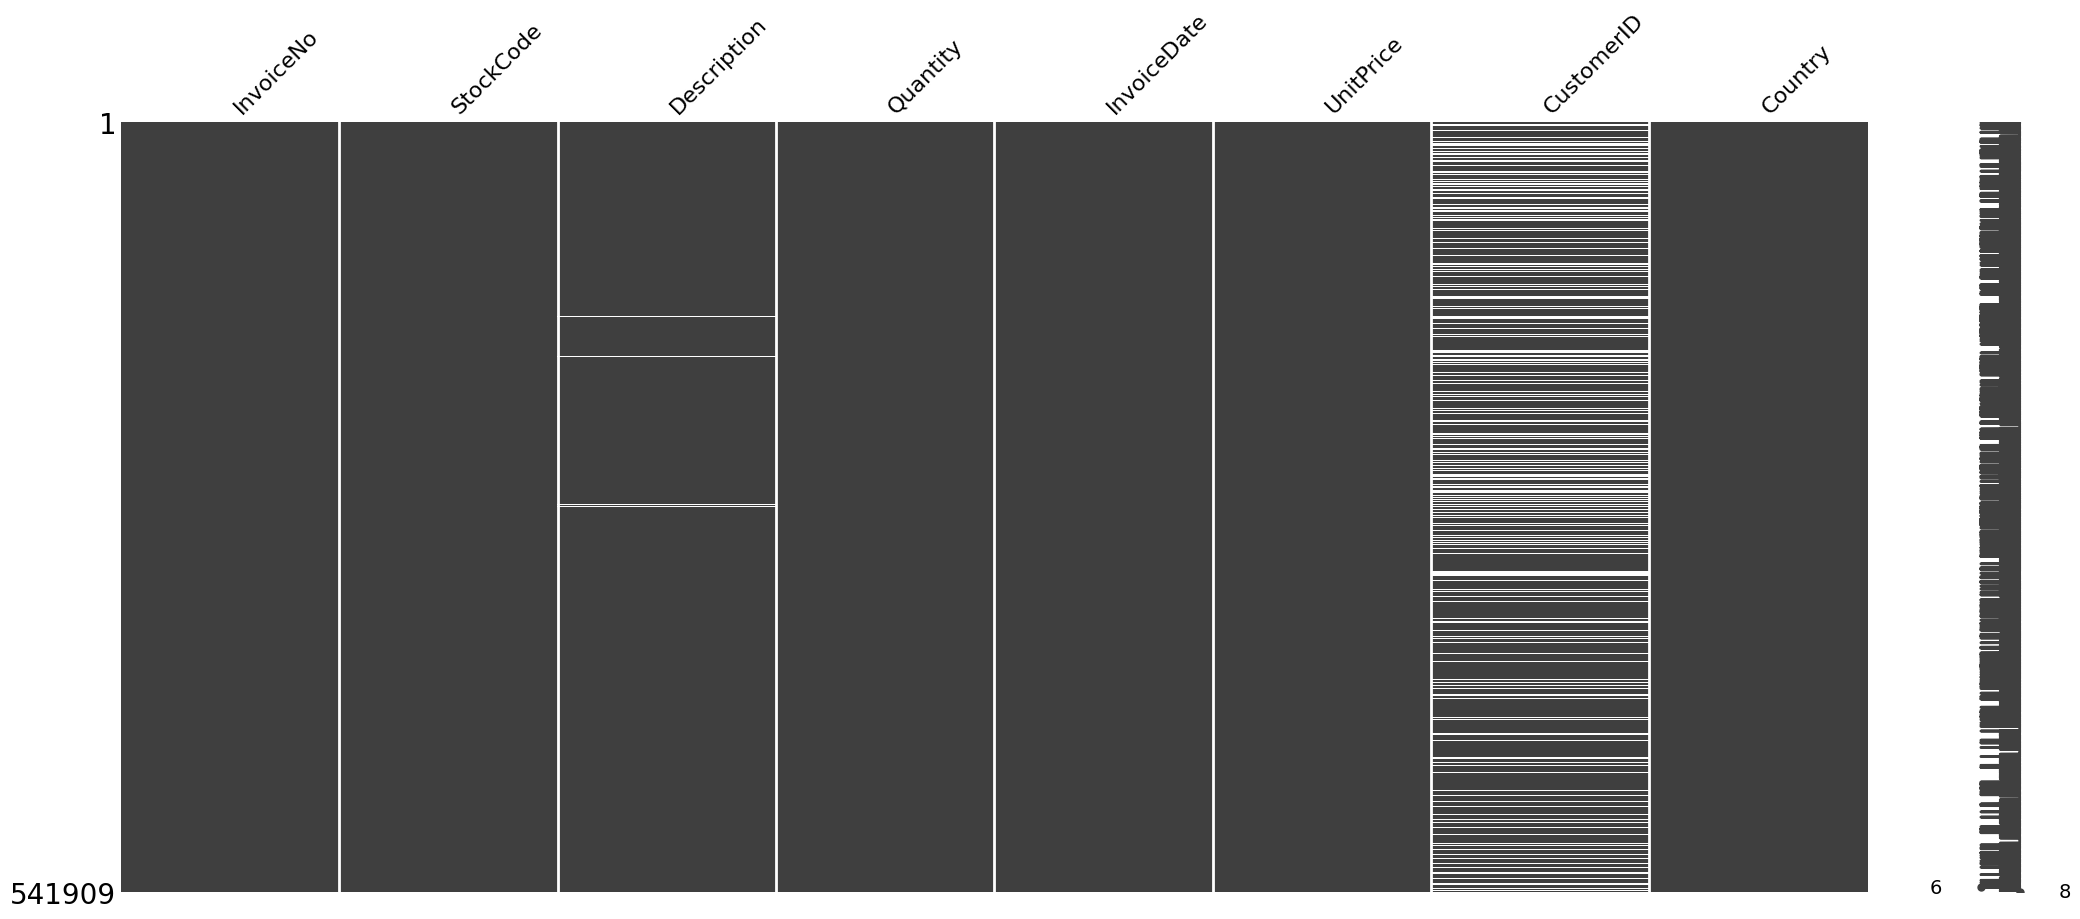

In [6]:
import missingno as msno
msno.matrix(df)
plt.show()

In [7]:
df.dropna(subset=['CustomerID'],how='all',inplace=True)

列名有大写有小写，同一为小写

In [8]:
df.columns = df.columns.str.lower()

有多少不同的国家？

In [9]:
df['country'].nunique()

37

对应行数最多的10个国家是啥？

In [10]:
df['country'].value_counts()[:10].index.tolist()

['United Kingdom',
 'Germany',
 'France',
 'EIRE',
 'Spain',
 'Netherlands',
 'Belgium',
 'Switzerland',
 'Portugal',
 'Australia']

TOP5贵的产品

In [11]:
df.sort_values(by='unitprice', ascending=False).head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
222681,C556445,M,Manual,-1,6/10/2011 15:31,38970.0,15098.0,United Kingdom
173382,551697,POST,POSTAGE,1,5/3/2011 13:46,8142.8,16029.0,United Kingdom
173277,C551685,POST,POSTAGE,-1,5/3/2011 12:51,8142.8,16029.0,United Kingdom
173391,C551699,M,Manual,-1,5/3/2011 14:12,6930.0,16029.0,United Kingdom
268027,C560372,M,Manual,-1,7/18/2011 12:26,4287.6,17448.0,United Kingdom


卖的最多的产品TOP5

In [12]:
df.groupby(["stockcode","description"]).agg({"quantity": lambda x: x.sum()})\
              .rename({'quantity':'total_quantity'},axis=1).nlargest(5,'total_quantity')

,,total_quantity
stockcode,description,
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,53215
85099B,JUMBO BAG RED RETROSPOT,45066
84879,ASSORTED COLOUR BIRD ORNAMENT,35314
85123A,WHITE HANGING HEART T-LIGHT HOLDER,34147
21212,PACK OF 72 RETROSPOT CAKE CASES,33409


In [13]:
print(f"StockCode的唯一值数量: {df['stockcode'].nunique()}")
print(f"Description的唯一值数量: {df['description'].nunique()}")

StockCode的唯一值数量: 3684
Description的唯一值数量: 3896


In [14]:
# drop剩下的缺失值
df = df.dropna()

In [15]:
df.describe([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
quantity,406829.0,12.1,248.7,-80995.0,-2.0,1.0,1.0,2.0,5.0,12.0,24.0,36.0,120.0,80995.0
unitprice,406829.0,3.5,69.3,0.0,0.2,0.4,0.6,1.2,1.9,3.8,6.8,8.5,15.0,38970.0
customerid,406829.0,15287.7,1713.6,12346.0,12415.0,12626.0,12876.0,13953.0,15152.0,16791.0,17719.0,17905.0,18212.0,18287.0


Quantity变量上有负值，这是由退款发票（包含字母"C"的发票）引起的

In [16]:
df = df[~df["invoiceno"].str.contains("C", na=False)]

In [17]:
df.describe([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
quantity,397924.0,13.0,180.4,1.0,1.0,1.0,1.0,2.0,6.0,12.0,24.0,36.0,120.0,80995.0
unitprice,397924.0,3.1,22.1,0.0,0.2,0.4,0.6,1.2,1.9,3.8,6.3,8.5,14.9,8142.8
customerid,397924.0,15294.3,1713.2,12346.0,12415.0,12627.0,12883.0,13969.0,15159.0,16795.0,17725.0,17912.0,18211.0,18287.0


排除异常值

In [18]:
df = df.query('quantity>0 and unitprice>0')

日期转换为年月日

In [19]:
pd.to_datetime(df['invoicedate'].str.split(expand = True).iloc[:,0])

0        2010-12-01
1        2010-12-01
2        2010-12-01
3        2010-12-01
4        2010-12-01
            ...    
541904   2011-12-09
541905   2011-12-09
541906   2011-12-09
541907   2011-12-09
541908   2011-12-09
Name: 0, Length: 397884, dtype: datetime64[ns]

In [20]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'].str.split(' ',expand=True).iloc[:,0])
df['invoicedate']

0        2010-12-01
1        2010-12-01
2        2010-12-01
3        2010-12-01
4        2010-12-01
            ...    
541904   2011-12-09
541905   2011-12-09
541906   2011-12-09
541907   2011-12-09
541908   2011-12-09
Name: invoicedate, Length: 397884, dtype: datetime64[ns]

In [21]:
# 增加用于分组的字段
df['year'] = df.invoicedate.dt.year
df['month'] = df.invoicedate.dt.month
df['months'] = df.year.astype(str) + '-' + df.month.astype(str)
df['totalcost'] =  df['unitprice'] * df['quantity']

In [22]:
df.dtypes

invoiceno              object
stockcode              object
description            object
quantity                int64
invoicedate    datetime64[ns]
unitprice             float64
customerid            float64
country                object
year                    int32
month                   int32
months                 object
totalcost             float64
dtype: object

In [23]:
df['customerid'] = df['customerid'].astype(int)

## RFM

### RFM Calculation

In [24]:
df

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,year,month,months,totalcost
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.5,17850,United Kingdom,2010,12,2010-12,15.3
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.4,17850,United Kingdom,2010,12,2010-12,20.3
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.8,17850,United Kingdom,2010,12,2010-12,22.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.4,17850,United Kingdom,2010,12,2010-12,20.3
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.4,17850,United Kingdom,2010,12,2010-12,20.3
...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09,0.8,12680,France,2011,12,2011-12,10.2
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09,2.1,12680,France,2011,12,2011-12,12.6
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09,4.2,12680,France,2011,12,2011-12,16.6
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09,4.2,12680,France,2011,12,2011-12,16.6


In [25]:
# 创建 RFM 表，使用 pivot_table 对 DataFrame 进行透视
rfm = df.pivot_table(
    index='customerid',  # 设置透视表的索引列为 'customerid'，每个客户对应一行
    values=["invoiceno", "totalcost", "invoicedate"],  # 需要进行聚合的列
    aggfunc={
        "invoiceno": pd.Series.nunique,  # 使用 pd.Series.nunique 计算每个客户的唯一发票数量
        "totalcost": "sum",  # 使用 "sum" 计算每个客户的总花费
        "invoicedate": "max"  # 使用 "max" 计算每个客户的最新购买日期
    }
)

1. **`df.pivot_table(...)`：** 该方法通过透视表的方式重新组织数据，以"customerid"作为索引，统计每个客户的相关信息。
2. **`index='customerid'`：** 通过设置索引为"customerid"，我们确保每个客户对应于透视表的一行。
3. **`values=["invoiceno", "totalcost", "invoicedate"]`：** 我们选择需要进行聚合的列，包括发票号("invoiceno")、总花费("totalcost")和发票日期("invoicedate")。
4. **`aggfunc={...}`：** 在`aggfunc`参数中，我们定义了对每个客户进行的聚合操作：
   - **`"invoiceno": pd.Series.nunique`：** 计算每个客户的唯一发票数量。`pd.Series.nunique`用于计算唯一值的数量。
   - **`"totalcost": "sum"`：** 计算每个客户的总花费，将所有花费相加。
   - **`"invoicedate": "max"`：** 计算每个客户的最新购买日期，取日期的最大值。
5. **结果：** 最终得到的`rfm`表包含每个客户的RFM信息，其中每一行代表一个客户，列包括唯一发票数量、总花费和最新购买日期。这种RFM分析可以用于客户细分和个性化营销。

In [26]:
# 所有用户最大的交易日期为标准，求每笔交易的时间间隔即为R
rfm['Recency'] = (rfm.invoicedate.max() - rfm.invoicedate) / np.timedelta64(1, 'D')

# # 每个客户的总销量即为F，总销售额即为M
rfm.rename(columns={
        "invoiceno": "Frequency",
        "totalcost": "Monetary"
    }, inplace = True)
rfm.head()

,invoicedate,Frequency,Monetary,Recency
customerid,,,,
12346,2011-01-18,1,77183.6,325.0
12347,2011-12-07,7,4310.0,2.0
12348,2011-09-25,4,1797.2,75.0
12349,2011-11-21,1,1757.5,18.0
12350,2011-02-02,1,334.4,310.0


如最近在做用户调研，根据用户的打分，将用户进行归类，在实际操作中，将用户归为三类（0-6一类，7-8一类等）

接着对客户价值进行标注，将客户分为8个等级。

![](https://image.woshipm.com/wp-files/2023/03/IT8NGS7FM3p418AgHzgh.png)


In [27]:
# 基于平均值做比较，超过均值为1，否则为0
rfm[['Recency','Frequency','Monetary']].apply(lambda x:(x-x.mean())/x.std())

def rfm_func(x):
    level = x.apply(lambda x:'1' if x > 0 else '0')
    level = level.Recency + level.Frequency + level.Monetary
    d = {
        "011": "High Value",
        "111": "Loyal",
        "001": "At Risk - High Value",
        "101": "Promising",
        "110": "Potential Loyalist",
        "010": "Regular",
        "100": "Hibernating",
        "000": "New/Low Activity"
    }
    result = d[level]
    return result

rfm['label']= rfm[['Recency','Frequency','Monetary']].apply(lambda x:(x-x.mean())/x.std()).apply(rfm_func, axis=1)
rfm.head()

,invoicedate,Frequency,Monetary,Recency,label
customerid,,,,,
12346,2011-01-18,1,77183.6,325.0,Promising
12347,2011-12-07,7,4310.0,2.0,High Value
12348,2011-09-25,4,1797.2,75.0,New/Low Activity
12349,2011-11-21,1,1757.5,18.0,New/Low Activity
12350,2011-02-02,1,334.4,310.0,Hibernating


Visualize high-value customers versus non-high-value customers.

In [28]:
rfm.label.unique()

array(['Promising', 'High Value', 'New/Low Activity', 'Hibernating',
       'At Risk - High Value', 'Regular', 'Potential Loyalist', 'Loyal'],
      dtype=object)

Compute the same logic with SQL

In [29]:
import sqlite3
import pandas as pd

df = load_local_data('../data/raw/rfm_stock_data.csv', 'csv', encoding='ISO-8859-1')
# Convert date format
df = df.dropna()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')
df['CustomerID'] = df['CustomerID'].astype(int)

# Create SQLite connection
conn = sqlite3.connect('rfm.db')
cursor = conn.cursor()

# Store DataFrame into SQLite table
df.to_sql('sales_data', conn, if_exists='replace', index=False)

406829

In [30]:
cursor.execute('''

WITH rfm_values AS (

    SELECT
        CustomerID,
        -- 计算每个客户的最后一次购买日期并将其转换为 YYYY-MM-DD 格式
        JULIANDAY((SELECT MAX(DATE(InvoiceDate)) FROM sales_data)) - JULIANDAY(MAX(DATE(InvoiceDate))) AS Recency,

        -- 计算购买频率
        COUNT(DISTINCT InvoiceNo) AS Frequency,

        -- 计算消费总金额
        SUM(Quantity * UnitPrice) AS Monetary
    FROM
        sales_data
    WHERE Quantity>0
    and UnitPrice>0
    -- df = df[~df["invoiceno"].str.contains("C", na=False)]
    and InvoiceNo not like '%C%'
    GROUP BY
        CustomerID
),
rfm_scores AS (
    SELECT
        *,
        NTILE(2) OVER (ORDER BY Recency ASC)-1 AS RecencyScore,
        NTILE(2) OVER (ORDER BY Frequency ASC)-1 AS FrequencyScore,
        NTILE(2) OVER (ORDER BY Monetary ASC)-1 AS MonetaryScore
    FROM
        rfm_values
)
SELECT
    CustomerID,
    Recency,
    Frequency,
    Monetary,
    (RecencyScore || FrequencyScore || MonetaryScore) AS RFM_Segment,
    CASE (RecencyScore || FrequencyScore || MonetaryScore)
        WHEN '011' THEN 'High Value'
        WHEN '111' THEN 'Loyal'
        WHEN '001' THEN 'At Risk - High Value'
        WHEN '101' THEN 'Promising'
        WHEN '110' THEN 'Potential Loyalist'
        WHEN '010' THEN 'Regular'
        WHEN '100' THEN 'Hibernating'
        WHEN '000' THEN 'New/Low Activity'
        ELSE 'Unknown Segment'
    END AS tag
FROM
    rfm_scores
ORDER BY
    CustomerID;



''')


# 获取结果
results = cursor.fetchall()
columns = [description[0] for description in cursor.description]
rfm_df = pd.DataFrame(results, columns=columns)

In [31]:
rfm_df.set_index('CustomerID')

,Recency,Frequency,Monetary,RFM_Segment,tag
CustomerID,,,,,
12346,325.0,1,77183.6,101,Promising
12347,2.0,7,4310.0,011,High Value
12348,75.0,4,1797.2,111,Loyal
12349,18.0,1,1757.5,001,At Risk - High Value
12350,310.0,1,334.4,100,Hibernating
...,...,...,...,...,...
18280,277.0,1,180.6,100,Hibernating
18281,180.0,1,80.8,100,Hibernating
18282,7.0,2,178.1,000,New/Low Activity


In [32]:
rfm

,invoicedate,Frequency,Monetary,Recency,label
customerid,,,,,
12346,2011-01-18,1,77183.6,325.0,Promising
12347,2011-12-07,7,4310.0,2.0,High Value
12348,2011-09-25,4,1797.2,75.0,New/Low Activity
12349,2011-11-21,1,1757.5,18.0,New/Low Activity
12350,2011-02-02,1,334.4,310.0,Hibernating
...,...,...,...,...,...
18280,2011-03-07,1,180.6,277.0,Hibernating
18281,2011-06-12,1,80.8,180.0,Hibernating
18282,2011-12-02,2,178.1,7.0,New/Low Activity


### 可视化

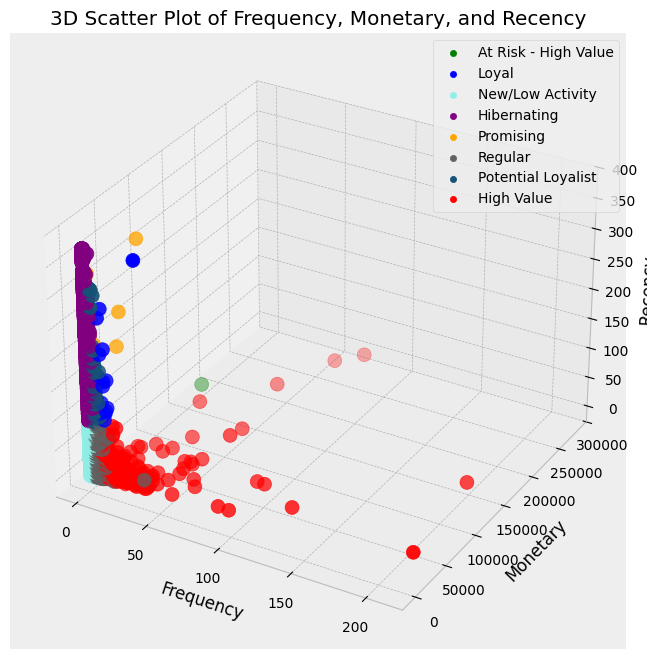

In [33]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 创建3D图
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

df = rfm.copy()


# Color mapping by segment label
colors = {'At Risk - High Value': 'green',
      'Loyal': 'blue',
      'New/Low Activity': '#91eee7',
      'Hibernating': 'purple',
      'Promising': 'orange',
      'Regular': '#616161',
      'Potential Loyalist': '#165376',
      'High Value': 'red',}

# Check if all labels in the DataFrame are in the colors dictionary
invalid_labels = set(df['label'].unique()) - set(colors.keys())
if invalid_labels:
    raise ValueError(f"The following labels do not have corresponding colors: {invalid_labels}")

# 绘制散点图
scatter = ax.scatter(
    df['Frequency'],
    df['Monetary'],
    df['Recency'],
    c=df['label'].map(colors),  # 使用map方法将label映射到颜色
    s=100
)

# 添加坐标轴标签
ax.set_xlabel('Frequency')
ax.set_ylabel('Monetary')
ax.set_zlabel('Recency')

# 添加图例
for label, color in colors.items():
    ax.scatter([], [], [], c=color, label=label)  # 添加空点作为图例项

# 设置图例
ax.legend()

# 设置图表标题
plt.title('3D Scatter Plot of Frequency, Monetary, and Recency')

# 显示图表
plt.show()


In [34]:
import plotly.express as px
import pandas as pd

# Your DataFrame
df = rfm.copy()

# Your color mapping
colors = {'At Risk - High Value': 'green',
      'Loyal': 'blue',
      'New/Low Activity': '#91eee7',
      'Hibernating': 'purple',
      'Promising': 'orange',
      'Regular': '#616161',
      'Potential Loyalist': '#165376',
      'High Value': 'red',}

# Check if all labels in the DataFrame are in the colors dictionary
invalid_labels = set(df['label'].unique()) - set(colors.keys())
if invalid_labels:
    raise ValueError(f"The following labels do not have corresponding colors: {invalid_labels}")

# Create 3D scatter plot
fig = px.scatter_3d(
    df,
    x='Frequency',
    y='Monetary',
    z='Recency',
    color='label',
    color_discrete_map=colors,
    symbol='label',
    size_max=2,
    opacity=0.7,
    labels={'Frequency': 'Frequency', 'Monetary': 'Monetary', 'Recency': 'Recency'},
    title='3D Scatter Plot of Frequency, Monetary, and Recency',
)

# 将图表保存为HTML文件
plotly_html_file = "plotly_example.html"
fig.write_html(plotly_html_file)

但是股票交易场景下，对于客户的分层和定义会不一样。

我们常使用kmeans做聚类，再进一步分析

### K-Means

#### 什么是无监督学习？

**无监督学习就是在没有标签数据的情况下，在现有已知的特征里寻找数据的“潜在结构”（pattern）**，所以比起监督学习，无监督学习要更难一些。

**聚类**

聚类（clustering）算是比较常用且实用的无监督学习方法了！它主要用于数据分析，也用于监督学习的预处理（pre-proprecessing），聚类可帮助我们发现数据中的一些规律。说白了，聚类算法就是根据特定规则，把数据分类，输入只有数据的特征（无 label），而输出则是分类标签，我们要讨论的 K-Means 就是一种最常见的聚类算法。

**降维**

降维同样在数据分析和预处理上占有很重要的位置，帮助我们解析高维数据，例如我们接下来要具体讲的主成分分析（PCA）和奇异值分解（SVD）。我们可以把高维数据进行降维转换，得到在新的二维（或更高）的实数空间里的新特征，从而再利用聚类或者其他手段去发现数据的规律。

**话题分析**

话题分析涵盖在文本分析之中，大家都知道机器学习在文本分析上的应用十分广泛，也表现相当优异，话题分析自然也很受欢迎，其在于发现文本集合中每个文本的话题，而话题由单词的集合表示（假设我们有足够多的文本）。话题分析可以转换成概率模型估计问题或者降维问题。

**图分析**

很多情况下，数据是以图的形式存在，图数据表示实体之间的联系，包括有向图、无向图、超图等。图分析在于发掘隐藏在图中的统计规律和潜在结构，例如 PageRank 算法，给定一个有向图，定义在图上的马尔科夫链（随机游走），其在有向图上随机跳转，到达一个结点后以等概率跳转到链接出去的结点，不断持续下去，PageRank 算法是求解马尔科夫链（Markov Chain）的平稳分布（stationary distribution）的算法。

#### k均值实现

K 均值聚类是基于样本集合划分的聚类方法。K 均值聚类把样本集合划分为 K 个子集， 构成 K 个类，将 n 个样本分到 K 个类中，每个样本到其所属类的中心距离最小。每个样本只能属于一个类，所以其属于硬聚类算法。



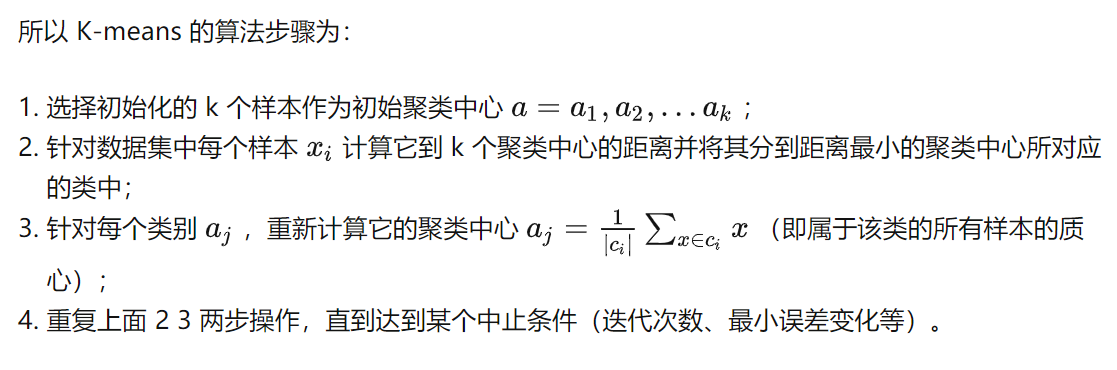

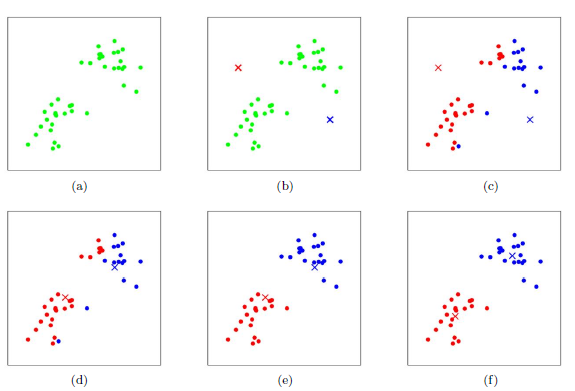

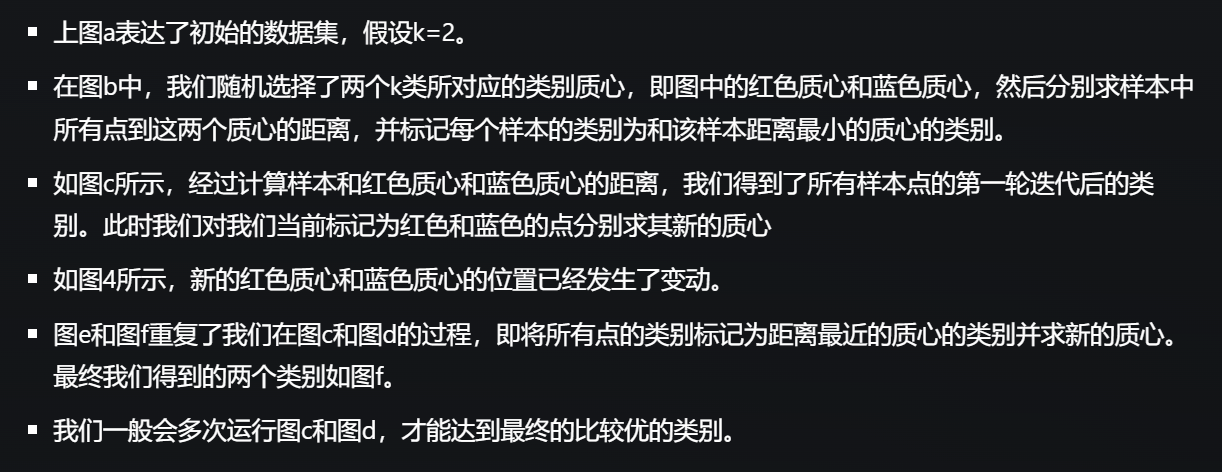

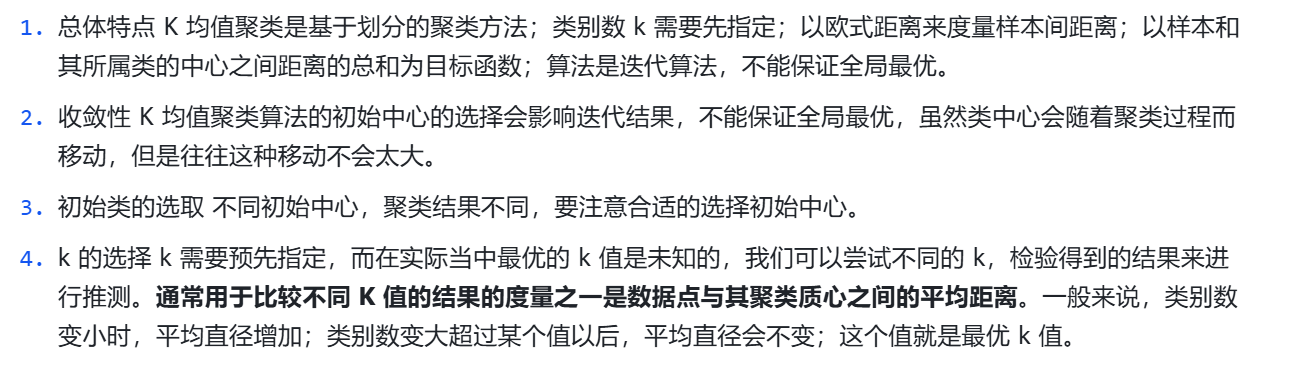

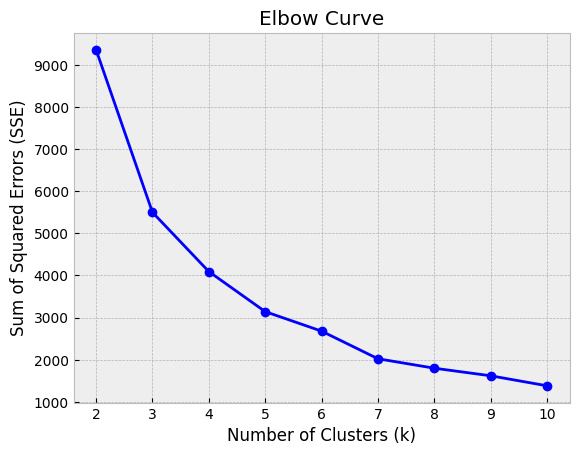

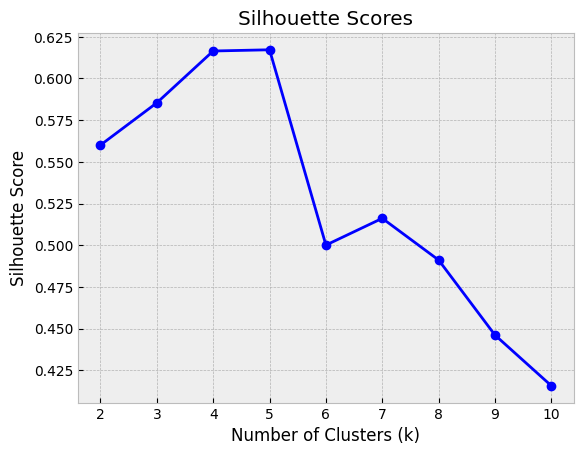

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 完全使用原始的特征，试一下kmeans
# rfm的基础上，再去加一些新的feat

rfm_segmentation = rfm[['Recency','Frequency','Monetary']].copy()

# Determine the optimal value of k using the elbow method
sse = []
silhouette_scores = []
k_values = range(2, 11)

X = rfm_segmentation.copy()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=1, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))


# kmeans++
#for k in k_values:
#    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
#    kmeans.fit(X)


# Plot the elbow curve
plt.plot(k_values, sse, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Curve')
plt.show()

# Plot the silhouette scores
plt.plot(k_values, silhouette_scores, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

通过RFM识别不同的客户群体，能够衡量客户价值和客户利润创收能力，可以指定个性化的沟通和营销服务，为更多的营销决策提供有力支持，为企业创造更大的利益。

In [36]:
#fitting data in Kmeans theorem.
kmeans = KMeans(n_clusters=3, random_state=0).fit(rfm_segmentation)

# this creates a new column called cluster which has cluster number for each row respectively.
rfm_segmentation['kmeans_cluster'] = kmeans.labels_

#check our hypothesis
rfm_segmentation[rfm_segmentation.kmeans_cluster == 0].head(10)

,Recency,Frequency,Monetary,kmeans_cluster
customerid,,,,
12347,2.0,7,4310.0,0
12348,75.0,4,1797.2,0
12349,18.0,1,1757.5,0
12350,310.0,1,334.4,0
12352,36.0,8,2506.0,0
12353,204.0,1,89.0,0
12354,232.0,1,1079.4,0
12355,214.0,1,459.4,0
12356,22.0,3,2811.4,0


## DBSCAN

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X = rfm[['Recency','Frequency','Monetary']].copy()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a DBSCAN instance
dbscan = DBSCAN(eps=0.2, min_samples=5)

# Fit the model and predict clusters
clusters = dbscan.fit_predict(X_scaled)

# Number of clusters in labels, ignoring noise if present
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

# Print the number of clusters and noise points
print('Estimated number of clusters:', n_clusters)
print('Estimated number of noise points:', n_noise)

Estimated number of clusters: 3
Estimated number of noise points: 162


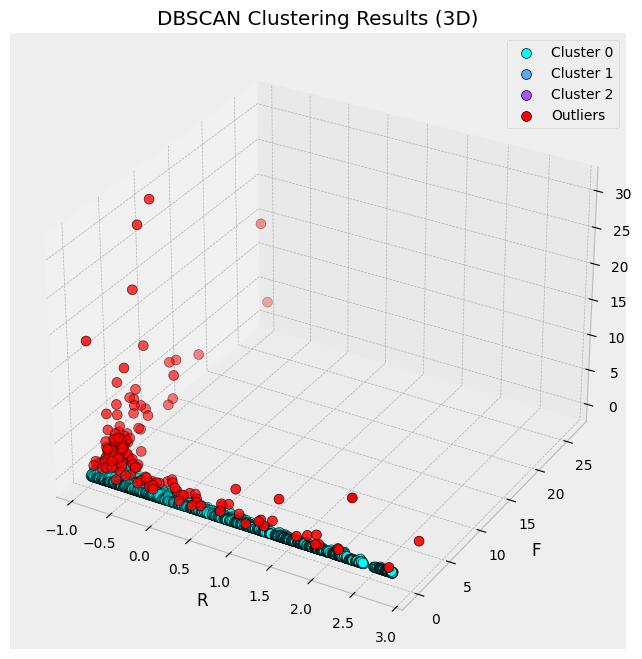

In [38]:
# Custom color map
custom_cmap = plt.cm.get_cmap('cool', len(set(clusters)))

# Visualize the clusters in 3D with custom colors
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotting clusters with legend
for cluster_label in set(clusters):
    if cluster_label == -1:
        # Plot outliers separately
        ax.scatter(
            X_scaled[clusters == cluster_label, 0],
            X_scaled[clusters == cluster_label, 1],
            X_scaled[clusters == cluster_label, 2],
            c='red',
            label='Outliers',
            marker='o',
            edgecolors='k',
            s=50
        )
    else:
        ax.scatter(
            X_scaled[clusters == cluster_label, 0],
            X_scaled[clusters == cluster_label, 1],
            X_scaled[clusters == cluster_label, 2],
            c=[custom_cmap(cluster_label)],
            label=f'Cluster {cluster_label}',
            marker='o',
            edgecolors='k',
            s=50
        )

ax.set_title('DBSCAN Clustering Results (3D)')
ax.set_xlabel('R')
ax.set_ylabel('F')
ax.set_zlabel('M')

# Add legend
ax.legend()

plt.show()


In [39]:
rfm_segmentation['DBSCAN_cluster'] = clusters

In [40]:
rfm_segmentation

,Recency,Frequency,Monetary,kmeans_cluster,DBSCAN_cluster
customerid,,,,,
12346,325.0,1,77183.6,2,-1
12347,2.0,7,4310.0,0,0
12348,75.0,4,1797.2,0,0
12349,18.0,1,1757.5,0,0
12350,310.0,1,334.4,0,0
...,...,...,...,...,...
18280,277.0,1,180.6,0,0
18281,180.0,1,80.8,0,0
18282,7.0,2,178.1,0,0


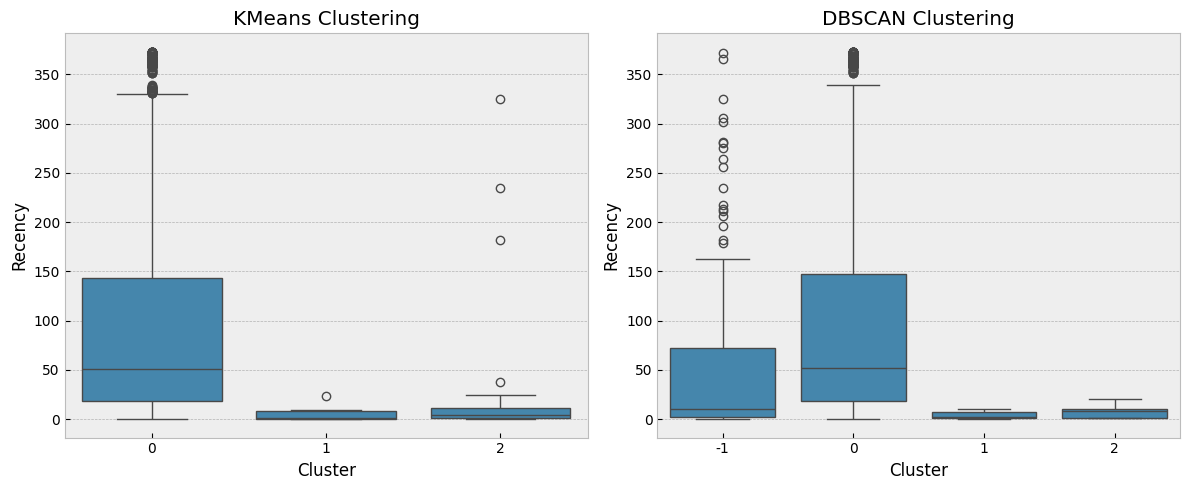

In [41]:
# Create a 1x2 subplot grid
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Subplot 1: Boxplot for KMeans clusters
sns.boxplot(x=rfm_segmentation['kmeans_cluster'], y=rfm_segmentation['Recency'], ax=axes[0])
axes[0].set_title('KMeans Clustering')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Recency')

# Subplot 2: Boxplot for DBSCAN clusters
sns.boxplot(x=rfm_segmentation['DBSCAN_cluster'], y=rfm_segmentation['Recency'], ax=axes[1])
axes[1].set_title('DBSCAN Clustering')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Recency')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

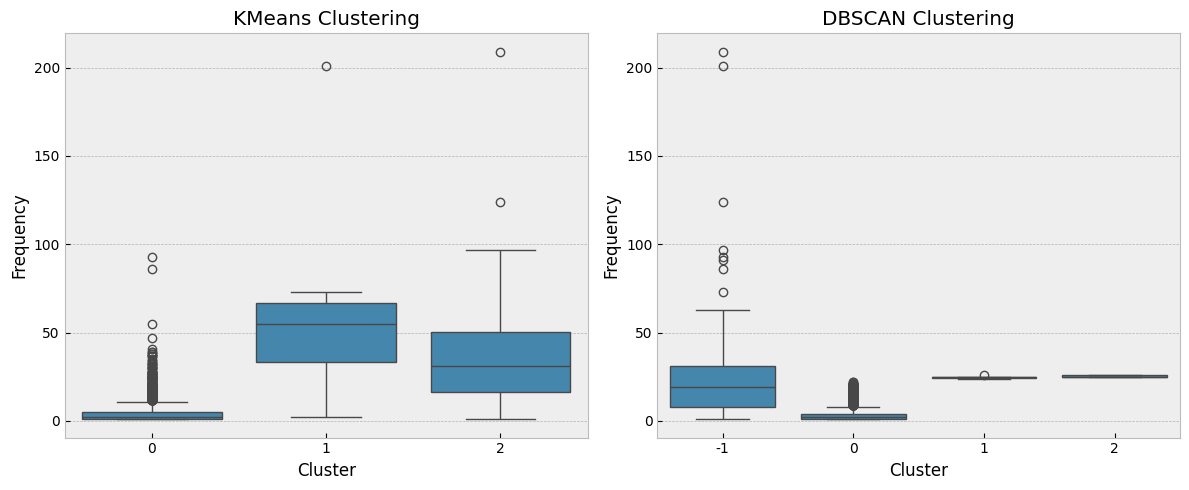

In [42]:
# Create a 1x2 subplot grid
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Subplot 1: Boxplot for KMeans clusters
sns.boxplot(x=rfm_segmentation['kmeans_cluster'], y=rfm_segmentation['Frequency'], ax=axes[0])
axes[0].set_title('KMeans Clustering')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Frequency')

# Subplot 2: Boxplot for DBSCAN clusters
sns.boxplot(x=rfm_segmentation['DBSCAN_cluster'], y=rfm_segmentation['Frequency'], ax=axes[1])
axes[1].set_title('DBSCAN Clustering')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

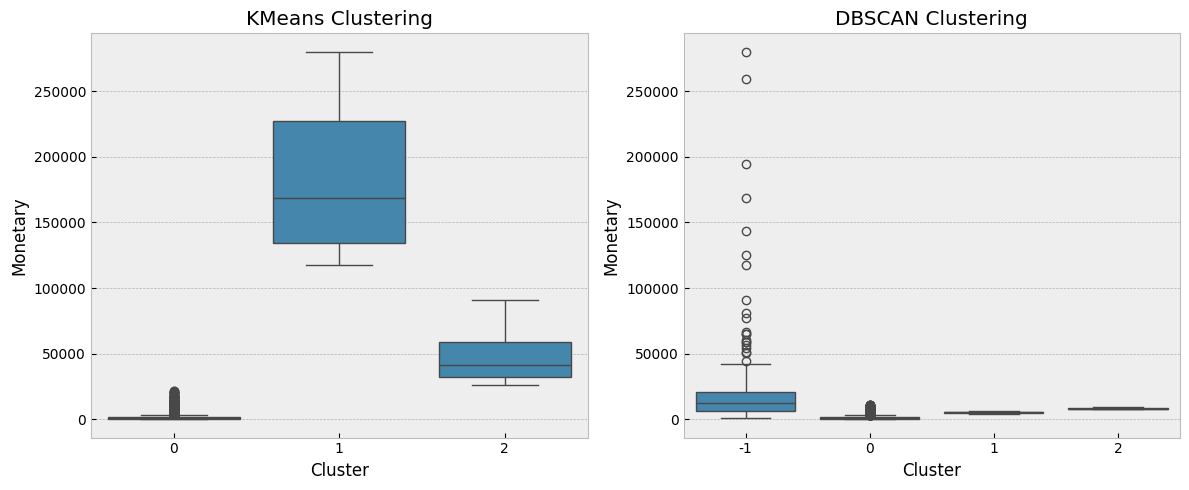

In [43]:
# Create a 1x2 subplot grid
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Subplot 1: Boxplot for KMeans clusters
sns.boxplot(x=rfm_segmentation['kmeans_cluster'], y=rfm_segmentation['Monetary'], ax=axes[0])
axes[0].set_title('KMeans Clustering')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Monetary')

# Subplot 2: Boxplot for DBSCAN clusters
sns.boxplot(x=rfm_segmentation['DBSCAN_cluster'], y=rfm_segmentation['Monetary'], ax=axes[1])
axes[1].set_title('DBSCAN Clustering')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Monetary')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

### 细分拆解

In [44]:
# Arguments (x = value, p = recency, monetary_value, frequency, d = quartiles dict)

#lower the recency, good for store..
def RScore(x,p,d):
    if x <= d[p][0.25]:
        return 1
    elif x <= d[p][0.50]:
        return 2
    elif x <= d[p][0.75]:
        return 3
    else:
        return 4


# Arguments (x = value, p = recency, monetary_value, frequency, k = quartiles dict)

#higher value of frequency and monetary lead to a good consumer. here higher value = 1 in reverse way.

def FMScore(x,p,d):
    if x <= d[p][0.25]:
        return 4
    elif x <= d[p][0.50]:
        return 3
    elif x <= d[p][0.75]:
        return 2
    else:
        return 1

In [45]:
'''
quantile is like 25% , 50% and 75% level of values. example if we have 100 values first 25 in 1st quartile 25%
then second contain next 25% which is 50% and there after next 25% which is 75% and 4th quartile is more than 75%
values.
'''
quantile = rfm[['Frequency','Monetary','Recency']].quantile(q=[0.25,0.5,0.75])
quantile

,Frequency,Monetary,Recency
0.2,1.0,307.4,17.0
0.5,2.0,674.5,50.0
0.8,5.0,1661.7,141.8


In [46]:
rfm_segmentation['R_Quartile'] = rfm_segmentation['Recency'].apply(RScore,args=('Recency',quantile))
rfm_segmentation['F_Quartile'] = rfm_segmentation['Frequency'].apply(FMScore, args=('Frequency',quantile))
rfm_segmentation['M_Quartile'] = rfm_segmentation['Monetary'].apply(FMScore, args=('Monetary',quantile))

In [47]:
#calculate RFM score..

rfm_segmentation['RFMScore'] = rfm_segmentation.R_Quartile.map(str) \
                            + rfm_segmentation.F_Quartile.map(str) \
                            + rfm_segmentation.M_Quartile.map(str)
rfm_segmentation.head()

,Recency,Frequency,Monetary,kmeans_cluster,DBSCAN_cluster,R_Quartile,F_Quartile,M_Quartile,RFMScore
customerid,,,,,,,,,
12346,325.0,1,77183.6,2,-1,4,4,1,441
12347,2.0,7,4310.0,0,0,1,1,1,111
12348,75.0,4,1797.2,0,0,3,2,1,321
12349,18.0,1,1757.5,0,0,2,4,1,241
12350,310.0,1,334.4,0,0,4,4,3,443


In [48]:
'''
Another possibility is to combine the scores to create one score (eg. 4+1+1). This will create a score
between 3 and 12. Here the advantage is that each of the scores got same importance. However some scores
will have many segments as constituents (eg - 413 ad 431)
'''

rfm_segmentation['Total_score'] = rfm_segmentation['R_Quartile'] + rfm_segmentation['F_Quartile'] + \
rfm_segmentation['M_Quartile']

In [49]:
rfm_segmentation.head()

,Recency,Frequency,Monetary,kmeans_cluster,DBSCAN_cluster,R_Quartile,F_Quartile,M_Quartile,RFMScore,Total_score
customerid,,,,,,,,,,
12346,325.0,1,77183.6,2,-1,4,4,1,441,9
12347,2.0,7,4310.0,0,0,1,1,1,111,3
12348,75.0,4,1797.2,0,0,3,2,1,321,6
12349,18.0,1,1757.5,0,0,2,4,1,241,7
12350,310.0,1,334.4,0,0,4,4,3,443,11


In [50]:
print("Best Customers: ",len(rfm_segmentation[rfm_segmentation['RFMScore']=='111']))
print('Loyal Customers: ',len(rfm_segmentation[rfm_segmentation['F_Quartile']==1]))
print("Big Spenders: ",len(rfm_segmentation[rfm_segmentation['M_Quartile']==1]))
print('Almost Lost: ', len(rfm_segmentation[rfm_segmentation['RFMScore']=='134']))
print('Lost Customers: ',len(rfm_segmentation[rfm_segmentation['RFMScore']=='344']))
print('Lost Cheap Customers: ',len(rfm_segmentation[rfm_segmentation['RFMScore']=='444']))

Best Customers:  456
Loyal Customers:  872
Big Spenders:  1085
Almost Lost:  34
Lost Customers:  208
Lost Cheap Customers:  444


In [51]:
rfm_segmentation.sort_values(by=['RFMScore', 'Monetary'], ascending=[True, False])

,Recency,Frequency,Monetary,kmeans_cluster,DBSCAN_cluster,R_Quartile,F_Quartile,M_Quartile,RFMScore,Total_score
customerid,,,,,,,,,,
14646,1.0,73,280206.0,1,-1,1,1,1,111,3
18102,0.0,60,259657.3,1,-1,1,1,1,111,3
17450,8.0,46,194550.8,1,-1,1,1,1,111,3
14911,1.0,201,143825.1,1,-1,1,1,1,111,3
14156,9.0,55,117379.6,1,-1,1,1,1,111,3
...,...,...,...,...,...,...,...,...,...,...
17102,261.0,1,25.5,0,0,4,4,4,444,12
15823,372.0,1,15.0,0,0,4,4,4,444,12
17763,263.0,1,15.0,0,0,4,4,4,444,12


In [52]:
rfm_segmentation.groupby('RFMScore')['Monetary'].mean()

RFMScore
111   9547.5
112   1286.3
113    511.3
114    253.9
121   2910.6
       ...  
434    214.6
441   8910.3
442    994.8
443    415.1
444    165.2
Name: Monetary, Length: 61, dtype: float64

In [53]:
rfm_segmentation.groupby('Total_score')['Monetary'].mean()

Total_score
3    9547.5
4    4164.1
5    2431.4
6    1456.7
7    1201.3
8     782.7
9     718.0
10    384.8
11    288.1
12    165.2
Name: Monetary, dtype: float64

<Axes: xlabel='Total_score'>

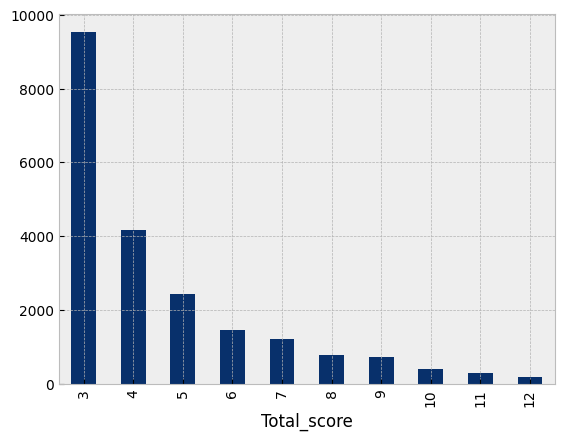

In [54]:
'''
Based on Monetary we see Total_score 3,4,5 have highest value which is good for model. because it could have
combination of values such as 111, 121, 122 etc.
'''
rfm_segmentation.groupby('Total_score')['Monetary'].mean().plot(kind='bar', colormap='Blues_r')

<Axes: xlabel='Total_score'>

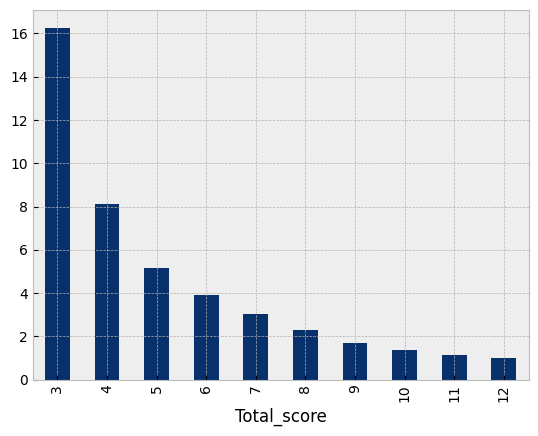

In [55]:
'''
Based on Frequncy we see Total_score 3,4,5 have highest value which is good for model. because it could have
combination of values such as 111, 121, 122 etc.
'''
rfm_segmentation.groupby('Total_score')['Frequency'].mean().plot(kind='bar', colormap='Blues_r')

<Axes: xlabel='Total_score'>

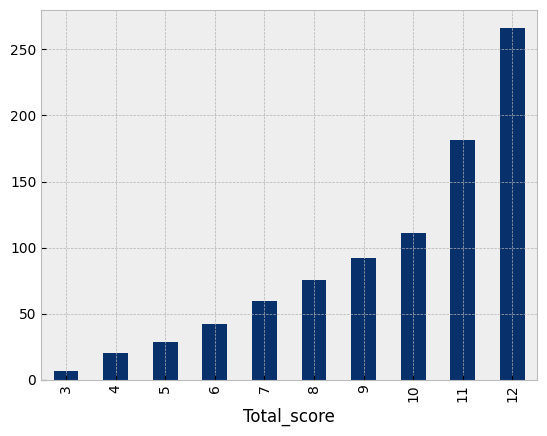

In [56]:
'''
Based on Recency we see Total_score 10,11,12 have highest value which is good for model. because it could have
combination of values such as 444, 434, 334 etc.
'''

rfm_segmentation.groupby('Total_score')['Recency'].mean().plot(kind='bar', colormap='Blues_r')

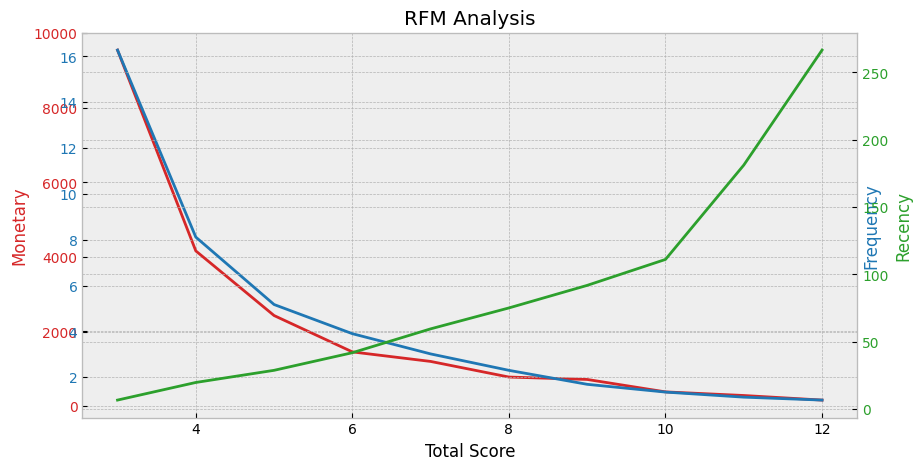

In [57]:
m = rfm_segmentation.groupby('Total_score')['Monetary'].mean()
f = rfm_segmentation.groupby('Total_score')['Frequency'].mean()
r = rfm_segmentation.groupby('Total_score')['Recency'].mean()

plt.style.use('bmh')
fig, ax1 = plt.subplots(figsize = [10,5])

color = 'tab:red'
ax1.plot(m.index, m.values,color=color)
ax1.set_title('RFM Analysis')
ax1.set_xlabel('Total Score')
ax1.set_ylabel('Monetary', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.plot(f.index, f.values,color=color)
ax2.set_ylabel('Frequency', color=color)
ax2.tick_params(axis='y', labelcolor=color)

ax3 = ax2.twinx()

color = 'tab:green'
ax3.plot(r.index, r.values,color=color)
ax3.set_ylabel('Recency', color=color)
ax3.tick_params(axis='y', labelcolor=color)

#fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()